In [3]:
import jax.numpy as jnp
from jax.scipy.special import logsumexp
from scipy.stats import norm
import numpy as np
import sys
import os
import jax

# Set the root directory path explicitly
root_dir = r"c:\Users\jimvo\Documents\Recurrent-PPO-Jax"
sys.path.append(root_dir)
# src\agents\ppo_dic_inherits\inh_agents\cor_gmm_agent.py

# Now import the class
from src.agents.ppo_dic_inherits.inh_agents.cor_gmm_agent import CorrelatedGaussianMixture
from src.agents.ppo_dic_inherits.inh_agents.cor_gmm_agent import CorrelatedGaussianMixture


In [ ]:
# Edits within the LowRankMVNSampling class in the Canvas:

# 1. Refine apply_padding_mask
def apply_padding_mask(self, data, masks):
     """Applies padding mask. Zeros out data where mask is False."""
     if masks is None:
         return data # Return unmodified data if no mask

     # Ensure mask is boolean
     masks = masks.astype(jnp.bool_)

     # Try to broadcast mask to data shape
     try:
         # Add trailing dimensions to mask if needed
         mask_ndim_diff = data.ndim - masks.ndim
         if mask_ndim_diff > 0:
             broadcast_shape = masks.shape + (1,) * mask_ndim_diff
             masks = jnp.broadcast_to(masks.reshape(broadcast_shape), data.shape)
         elif mask_ndim_diff < 0:
             # This case is less common, maybe data has extra dims?
             # Attempt to broadcast anyway if shapes compatible
             try:
                 masks = jnp.broadcast_to(masks, data.shape)
             except ValueError: # If broadcasting fails, maybe mask applies to leading dims only
                 if data.shape[:masks.ndim] == masks.shape:
                    # Assume mask applies to leading dimensions, keep where True
                    mask_expanded = masks.reshape(masks.shape + (1,) * mask_ndim_diff)
                    # This logic might need adjustment based on specific use case
                    # For now, we'll zero out based on leading dimensions
                    return jnp.where(mask_expanded, data, 0.0)
                 else:
                     raise # Re-raise original error if shapes incompatible
         else:
             # ndims match, broadcast if necessary (e.g. mask is [N,S,1], data is [N,S,d])
             masks = jnp.broadcast_to(masks, data.shape)

         # Apply mask (zero out entries where mask is False)
         # Use jnp.zeros_like(data) to handle dtype correctly
         return jnp.where(masks, data, jnp.zeros_like(data))

     except ValueError as e:
         print(f"Warning: Could not broadcast mask shape {masks.shape} to data shape {data.shape}. Error: {e}. Returning unmodified data.")
         return data

# 2. Modify sampling_differ to optionally return pre-tanh actions
def sampling_differ(self, act_logits, key, masks, return_pre_tanh=False):
    """
    Samples actions using a Low-Rank Multivariate Normal distribution.

    Args:
        act_logits: Raw output tensor from the policy network. [N, expected_logit_size].
        key: JAX random key.
        masks: Optional padding mask (applied AFTER sampling and tanh). [N] or compatible.
        return_pre_tanh: If True, also returns the actions before tanh.

    Returns:
        Sampled actions tensor of shape [N, s, a].
        If return_pre_tanh is True, returns (acts_tick, action_pre_tanh).
    """
    N = act_logits.shape[0] # JAX batch size (num environments)

    if act_logits.shape[-1] != self.expected_logit_size:
         raise ValueError(f"Network output dimension mismatch! Expected last dim {self.expected_logit_size}, got {act_logits.shape[-1]}.")

    mu = act_logits[..., :self.flat_action_dim]
    log_std = act_logits[..., self.flat_action_dim : 2 * self.flat_action_dim]
    V_flat = act_logits[..., 2 * self.flat_action_dim :]
    V = jnp.reshape(V_flat, (N, self.flat_action_dim, self.rank_k))

    sqrt_D_diag = jnp.exp(log_std) # [N, d]

    key_diag, key_rank = jax.random.split(key)
    z_diag = jax.random.normal(key_diag, shape=(N, self.flat_action_dim)) # [N, d]
    z_rank = jax.random.normal(key_rank, shape=(N, self.rank_k))          # [N, k]

    diag_contribution = sqrt_D_diag * z_diag  # [N, d]
    rank_contribution = jnp.einsum('Ndk,Nk->Nd', V, z_rank) # [N, d]
    action_flat = mu + diag_contribution + rank_contribution # [N, d]

    action_pre_tanh = jnp.reshape(action_flat, (N, self.batch_size, self.action_dim)) # [N, s, a]

    if self.apply_tanh:
        acts_tick = jnp.tanh(action_pre_tanh)
    else:
        acts_tick = action_pre_tanh

    # Apply mask to the final actions
    acts_tick_masked = self.apply_padding_mask(acts_tick, masks)

    if return_pre_tanh:
        # Also mask pre_tanh actions if needed for consistency in stats tests
        action_pre_tanh_masked = self.apply_padding_mask(action_pre_tanh, masks)
        return acts_tick_masked, action_pre_tanh_masked
    else:
        return acts_tick_masked

In [7]:
# %% Import necessary libraries
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns # Optional for nicer plots
import numpy as np # For meshgrid
from functools import partial # For vmapping functions with static args
from src.agents.ppo_dic_inherits.inh_agents.low_mvn_agent import LowRankMVN


# %% Import the class (assuming it's saved in low_rank_mvn.py)
# try:
#     from low_rank_mvn import LowRankMVNSampling
#     print("Successfully imported LowRankMVNSampling.")
# except ImportError:
#     print("Error: Could not import LowRankMVNSampling.")
#     print("Please ensure 'low_rank_mvn.py' containing the class is in the same directory.")
#     # Define a dummy class to avoid further errors in the script if needed
#     class LowRankMVNSampling:
#         def __init__(self, *args, **kwargs): pass
#         def sampling_differ(self, *args, **kwargs): pass
#         def log_prob(self, *args, **kwargs): pass
        # def entropy(self, *args, **kwargs): pass

# %% --- Configuration ---
# Distribution parameters
S_BATCH = 1 # Use s=1 for 2D visualization test
A_DIM = 2   # Use a=2 for 2D visualization test (d=2)
K_RANK = 1  # Rank (try varying this)
APPLY_TANH = False # Set to True to test tanh squashing
FLAT_DIM = S_BATCH * A_DIM # d

# Testing parameters
NUM_SAMPLES = 10000 # For statistical tests
GRID_POINTS = 100  # For density plots
N_ENVS = 1 # Number of parallel environments for testing shapes (can increase)
S_STEPS = 1 # Number of time steps for testing shapes (can increase)

# Random key
key = jax.random.PRNGKey(42)

# %% --- Instantiate Sampler ---
sampler = LowRankMVN(
    max_batch=S_BATCH,
    action_dim=A_DIM,
    sampling_distribution=K_RANK,
    # apply_tanh=APPLY_TANH
)
print(f"\nSampler instantiated with d={sampler.flat_action_dim}, k={sampler.rank_k}")

# %% --- Generate Fixed Distribution Parameters (act_logits) ---
key, subkey = jax.random.split(key)
# Example: Centered mean, moderate diagonal std dev, small V component
fixed_mu = jnp.array([0.5, -0.5]) # Shape [d]
fixed_log_std = jnp.log(jnp.array([0.5, 0.8])) # Shape [d] -> stds [0.5, 0.8]
fixed_V = jax.random.normal(subkey, (FLAT_DIM, K_RANK)) * 0.3 # Shape [d, k]

# Combine into act_logits for N=1, S=1
fixed_logits_single = jnp.concatenate([
    fixed_mu,
    fixed_log_std,
    fixed_V.flatten()
])[None, None, :] # Add N and S dimensions -> Shape [1, 1, expected_logit_size]

print(f"\nUsing fixed distribution parameters (N=1, S=1):")
print(f" mu = {fixed_mu}")
print(f" std = {jnp.exp(fixed_log_std)}")
# print(f" V = \n{fixed_V}") # Can be large

# %% --- Test 1: Visual Sampling vs. Log Probability (d=2) ---
print("\n--- Test 1: Visual Sampling vs. Log Probability ---")
if FLAT_DIM != 2:
    print(f"Skipping visual test because dimension d={FLAT_DIM} is not 2.")
else:
    # --- Generate Samples ---
    key, *sample_keys = jax.random.split(key, NUM_SAMPLES + 1)
    sample_keys = jnp.array(sample_keys)

    # Jit the sampling function for speed
    # Note: sampling_differ expects N dim, so use logits[0,0,:] and add N dim back
    @jax.jit
    def sample_one(k):
         # Sample one action (shape [1, s, a]), squeeze N dim out
         # Pass None for mask
         act, pre_tanh = sampler.sampling_differ(fixed_logits_single[0], k, masks=None)
         # Return pre-tanh for plotting the base MVN distribution
         return pre_tanh[0] # Shape [s, a]

    # Vmap over keys
    samples_pre_tanh = jax.vmap(sample_one)(sample_keys) # Shape [NUM_SAMPLES, s, a]
    # Reshape samples to [NUM_SAMPLES, d] for plotting
    samples_flat = samples_pre_tanh.reshape(NUM_SAMPLES, FLAT_DIM)
    print(f"Generated {NUM_SAMPLES} samples (pre-tanh). Shape: {samples_flat.shape}")

    # --- Calculate Log Prob Density on a Grid ---
    # Determine plot range based on samples
    min_vals = jnp.min(samples_flat, axis=0) - 1.0
    max_vals = jnp.max(samples_flat, axis=0) + 1.0

    # Create grid
    x_grid = np.linspace(min_vals[0], max_vals[0], GRID_POINTS)
    y_grid = np.linspace(min_vals[1], max_vals[1], GRID_POINTS)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid_flat = np.vstack([xx.ravel(), yy.ravel()]).T # Shape [GRID_POINTS^2, 2]

    # Reshape grid points to match expected action input [N, S, s, a]
    # Here N=GRID_POINTS^2, S=1, s=S_BATCH, a=A_DIM
    grid_actions = jnp.array(grid_flat).reshape(GRID_POINTS*GRID_POINTS, 1, S_BATCH, A_DIM)

    # Prepare corresponding logits (repeat the fixed logits)
    grid_logits = jnp.repeat(fixed_logits_single, GRID_POINTS*GRID_POINTS, axis=0) # Shape [GRID_POINTS^2, 1, expected_logit_size]

    # Jit the log_prob function
    # Note: log_prob expects [N, S, ...] inputs
    @jax.jit
    def calculate_log_probs(actions, logits):
        return sampler.log_prob(actions, logits)

    # Calculate log probs
    log_probs_grid = calculate_log_probs(grid_actions, grid_logits) # Shape [GRID_POINTS^2, 1]
    log_probs_grid = log_probs_grid.flatten() # Shape [GRID_POINTS^2]
    # Convert to probability density (handle potential underflow/overflow)
    probs_grid = jnp.exp(log_probs_grid - jnp.max(log_probs_grid)) # Normalize peak to 1 for visualization
    probs_grid_reshaped = probs_grid.reshape(GRID_POINTS, GRID_POINTS)
    print("Calculated probability density on grid.")

    # --- Plotting ---
    plt.figure(figsize=(10, 8))
    # Plot density contours
    contour = plt.contourf(xx, yy, probs_grid_reshaped, levels=20, cmap='viridis', alpha=0.8)
    plt.colorbar(contour, label='Relative Probability Density')
    # Overlay samples
    plt.scatter(samples_flat[:, 0], samples_flat[:, 1], s=1, alpha=0.1, color='red', label=f'{NUM_SAMPLES} Samples')
    # Plot theoretical mean
    plt.scatter(fixed_mu[0], fixed_mu[1], marker='x', s=100, color='black', label='Theoretical Mean (mu)')

    plt.title(f'Sampling Distribution vs. Log Probability Density (d=2, k={K_RANK}, tanh={APPLY_TANH})')
    plt.xlabel('Action Dimension 1')
    plt.ylabel('Action Dimension 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# %% --- Test 2: Entropy Consistency ---
print("\n--- Test 2: Entropy Consistency ---")
key, subkey1, subkey2 = jax.random.split(key, 3)

# Low variance parameters
logits_low_var = jnp.concatenate([
    jnp.zeros(FLAT_DIM), # Zero mean
    jnp.log(jnp.ones(FLAT_DIM) * 0.1), # Small std dev (0.1)
    (jax.random.normal(subkey1, (FLAT_DIM, K_RANK)) * 0.01).flatten() # Very small V
])[None, None, :] # Shape [1, 1, ...]

# High variance parameters
logits_high_var = jnp.concatenate([
    jnp.zeros(FLAT_DIM), # Zero mean
    jnp.log(jnp.ones(FLAT_DIM) * 1.0), # Larger std dev (1.0)
    (jax.random.normal(subkey2, (FLAT_DIM, K_RANK)) * 0.5).flatten() # Larger V
])[None, None, :] # Shape [1, 1, ...]

# Jit entropy calculation
@jax.jit
def calculate_entropy(logits):
    # Pass None for mask
    return sampler.entropy(logits, masks=None)

entropy_low = calculate_entropy(logits_low_var)[0, 0] # Extract scalar value
entropy_high = calculate_entropy(logits_high_var)[0, 0]

print(f"Entropy (Low Variance): {entropy_low:.4f}")
print(f"Entropy (High Variance): {entropy_high:.4f}")

try:
    assert entropy_high > entropy_low
    print("Consistency Check PASSED: Higher variance resulted in higher entropy.")
except AssertionError:
    print("Consistency Check FAILED: Higher variance did NOT result in higher entropy!")

# %% --- Test 3: Entropy Analytic Check (Diagonal Case, k=0) ---
print("\n--- Test 3: Entropy Analytic Check (Diagonal Case, k=0) ---")
# Instantiate sampler with k=0
sampler_k0 = LowRankMVN(
    max_batch=S_BATCH,
    action_dim=A_DIM,
    sampling_distribution=0,
    # apply_tanh=APPLY_TANH # Tanh doesn't affect base entropy calculation
)

# Define parameters (V is now empty)
fixed_mu_k0 = jnp.array([0.1, 0.2])[:FLAT_DIM] # Use correct dimension
fixed_log_std_k0 = jnp.log(jnp.array([0.5, 1.5]))[:FLAT_DIM] # Use correct dimension
logits_k0 = jnp.concatenate([fixed_mu_k0, fixed_log_std_k0])[None, None, :] # Shape [1, 1, d*2]

# Calculate entropy using the class method
entropy_calculated_k0 = sampler_k0.entropy(logits_k0)[0, 0]

# Calculate entropy analytically for diagonal MVN
# H = 0.5 * log det(D) + 0.5 * d * (1 + log(2*pi))
# H = 0.5 * sum(2*log_std) + sampler_k0._entropy_offset
# H = sum(log_std) + sampler_k0._entropy_offset
analytic_entropy_k0 = jnp.sum(fixed_log_std_k0) + sampler_k0._entropy_offset

print(f"Entropy (Calculated, k=0): {entropy_calculated_k0:.4f}")
print(f"Entropy (Analytic, k=0):   {analytic_entropy_k0:.4f}")

try:
    assert jnp.allclose(entropy_calculated_k0, analytic_entropy_k0)
    print("Analytic Check PASSED: Calculated entropy matches analytic formula for k=0.")
except AssertionError:
    print("Analytic Check FAILED: Calculated entropy does NOT match analytic formula for k=0!")

# %% --- Test 4: Sampling Statistics (Mean and Covariance) ---
print("\n--- Test 4: Sampling Statistics (Mean and Covariance) ---")
# Reuse fixed_logits_single from Test 1

# --- Generate many samples (pre-tanh) ---
key, *sample_keys = jax.random.split(key, NUM_SAMPLES + 1)
sample_keys = jnp.array(sample_keys)

# Jit the sampling function to return pre-tanh
@jax.jit
def sample_one_pre_tanh(k):
     act, pre_tanh = sampler.sampling_differ(fixed_logits_single[0], k, masks=None, return_pre_tanh=True)
     return pre_tanh[0] # Shape [s, a]

samples_pre_tanh = jax.vmap(sample_one_pre_tanh)(sample_keys) # Shape [NUM_SAMPLES, s, a]
samples_flat = samples_pre_tanh.reshape(NUM_SAMPLES, FLAT_DIM) # Shape [NUM_SAMPLES, d]

# --- Calculate Empirical Stats ---
empirical_mean = jnp.mean(samples_flat, axis=0)
empirical_cov = jnp.cov(samples_flat, rowvar=False)

# --- Calculate Theoretical Stats ---
theoretical_mean = fixed_mu
# Sigma = D + V*V^T
D = jnp.diag(jnp.exp(2 * fixed_log_std))
VVT = fixed_V @ fixed_V.T
theoretical_cov = D + VVT

print(f"Theoretical Mean: {theoretical_mean}")
print(f"Empirical Mean:   {empirical_mean}")
print(f"Theoretical Covariance:\n{theoretical_cov}")
print(f"Empirical Covariance:\n{empirical_cov}")

# --- Compare ---
mean_close = jnp.allclose(theoretical_mean, empirical_mean, atol=0.1) # Tolerance depends on NUM_SAMPLES
cov_close = jnp.allclose(theoretical_cov, empirical_cov, atol=0.1)   # Tolerance depends on NUM_SAMPLES

print(f"\nMean Check Close: {mean_close}")
print(f"Covariance Check Close: {cov_close}")
if not mean_close or not cov_close:
    print("Note: Statistical tests require large NUM_SAMPLES for high accuracy.")

# %% --- Test 5: Log Prob Boundary Check (if apply_tanh=True) ---
print("\n--- Test 5: Log Prob Boundary Check ---")
if not APPLY_TANH:
    print("Skipping boundary check because apply_tanh is False.")
else:
    # Create actions near boundaries
    actions_near_boundary = jnp.array([
        [-0.9999, 0.9999],
        [ 0.9999, -0.9999]
    ])[:FLAT_DIM] # Ensure correct dimension if d=1

    if actions_near_boundary.shape[0] != FLAT_DIM:
         print(f"Skipping boundary check for d={FLAT_DIM}") # Only check for d=2 easily
    else:
        actions_boundary_reshaped = actions_near_boundary.reshape(1, 1, S_BATCH, A_DIM) # Shape [1, 1, s, a]

        # Calculate log_prob
        log_prob_boundary = sampler.log_prob(actions_boundary_reshaped, fixed_logits_single)
        print(f"Log prob for actions near +/-1: {log_prob_boundary[0, 0]:.4f}")

        try:
            assert jnp.isfinite(log_prob_boundary)
            print("Boundary Check PASSED: Log prob is finite for actions near +/-1.")
        except AssertionError:
            print("Boundary Check FAILED: Log prob is NaN or Inf for actions near +/-1!")

# %% --- Test 6: Masking Check ---
print("\n--- Test 6: Masking Check ---")
N_mask_test = 4
S_mask_test = 5
key, subkey = jax.random.split(key)
mask_test = jax.random.bernoulli(subkey, 0.7, shape=(N_mask_test, S_mask_test)) # Boolean mask [N, S]

# Generate logits for multiple envs/steps
key, subkey = jax.random.split(key)
logits_mask_test = jax.random.normal(subkey, (N_mask_test, S_mask_test, sampler.expected_logit_size)) * 0.1
logits_mask_test = logits_mask_test.at[..., FLAT_DIM:2*FLAT_DIM].add(-1.0) # Negative log_std

# Calculate entropy with mask
entropy_masked = sampler.entropy(logits_mask_test, masks=mask_test)

# Calculate entropy without mask
entropy_unmasked = sampler.entropy(logits_mask_test, masks=None)

print("Mask:\n", mask_test.astype(int))
print("Entropy (Unmasked):\n", entropy_unmasked)
print("Entropy (Masked):\n", entropy_masked)

# Check if entropy is zero where mask is False
masked_correctly = jnp.all((entropy_masked == 0.0) == (~mask_test))

try:
    assert masked_correctly
    print("\nMasking Check PASSED: Entropy is zero where mask is False.")
except AssertionError:
    print("\nMasking Check FAILED: Entropy is NOT zero where mask is False!")

# Test masking for log_prob (requires dummy actions)
key, subkey = jax.random.split(key)
actions_mask_test = jax.random.uniform(key, (N_mask_test, S_mask_test, S_BATCH, A_DIM), minval=-0.9, maxval=0.9)
logprob_masked = sampler.log_prob(actions_mask_test, logits_mask_test)
# Apply mask manually for comparison
logprob_masked_manual = jnp.where(mask_test, logprob_masked, 0.0)

# Note: log_prob itself doesn't take the mask, the loss function usually applies it.
# Let's test if apply_padding_mask works as expected on a generic array
generic_data = jnp.ones((N_mask_test, S_mask_test))
generic_masked = sampler.apply_padding_mask(generic_data, mask_test)
masking_generic_correct = jnp.all((generic_masked == 0.0) == (~mask_test))
print(f"\nGeneric Masking Correct: {masking_generic_correct}")


print("\n--- All Tests Completed ---")



LowRankMVNSampling initialized: s=1, a=2, k=1
Flattened action dimension: 2
Expected network output size per action: 6

Sampler instantiated with d=2, k=1

Using fixed distribution parameters (N=1, S=1):
 mu = [ 0.5 -0.5]
 std = [0.5 0.8]

--- Test 1: Visual Sampling vs. Log Probability ---


ValueError: cannot select an axis to squeeze out which has size not equal to one, got shape=(1, 2) and dimensions=(1,)

In [2]:


def test_gmm_log_prob_single():
    # Setup
    means = jnp.array([0.0, 2.0])        # Means of two Gaussians
    stds = jnp.array([1.0, 1.0])         # Std devs
    weights = jnp.array([0.3, 0.7])      # Mixture weights (must sum to 1)
    
    action = jnp.array(0.5)              # Action to evaluate
    u = jnp.arctanh(jnp.clip(action, -0.999, 0.999))  # unsquash
    
    # Manual computation of log prob (unbatched)
    log_probs = jnp.array([norm.logpdf(u, loc=m, scale=s) for m, s in zip(means, stds)])
    log_weights = jnp.log(weights)
    base_log_prob = logsumexp(log_weights + log_probs)
    
    # Tanh correction
    log_det_jacobian = 2 * (jnp.log(2) - u - jax.nn.softplus(-2 * u))
    final_log_prob = base_log_prob - log_det_jacobian
    
    print(f"Manual log-prob: {final_log_prob}")

    # Now format inputs for your function
    N, S, B, A, K = 1, 1, 1, 1, 2
    
    # GMM logits: [weights logits | means | stds]
    logit_weights = jnp.log(weights)
    means = means.reshape((1, 1, 1, A, K))
    stds = stds.reshape((1, 1, 1, A, K))
    
    weight_logits = logit_weights.reshape((1, 1, 1, A, K))
    gmm_params = jnp.concatenate([means.squeeze(), stds.squeeze()], axis=-1)
    gmm_params = gmm_params.reshape((1, 1, 1, A * K * 2))  # [N, S, B, A*K*2]
    act_logits = jnp.concatenate([weight_logits.reshape(1, 1, 1, A * K), gmm_params], axis=-1)  # shape [1, 1, 1, A*K + A*K*2]

    actions = action.reshape((1, 1, 1, 1))

    # Call your function
    model = CorrelatedGaussianMixture(1,1,2)  # replace with actual model instance
    log_prob = model.gaussian_log_prob(actions, act_logits)

    print(f"Function log-prob: {log_prob}")

    # Compare
    np.testing.assert_allclose(log_prob, final_log_prob, rtol=1e-5)
    print("Test passed!")

test_gmm_log_prob_single()


Manual log-prob: -1.3196299076080322
u_expanded shape (1, 1, 1, 1, 2) means_all shape (1, 1, 1, 1, 2) scale_all shape (1, 1, 1, 1, 2) (1, 1, 1, 1, 2)
Function log-prob: [[-1.3196299]]
Test passed!


In [8]:
def test_entropy_single():  
    means = jnp.array([0.0, 2.0])        # Means of two Gaussians
    stds = jnp.array([1.0, 1.0])         # Std devs
    weights = jnp.array([0.3, 0.7])      # Mixture weights (must sum to 1)
    
    action = jnp.array(0.5)              # Action to evaluate
    
    # Now format inputs for your function
    N, S, B, A, K = 1, 1, 1, 1, 2
    
    # GMM logits: [weights logits | means | stds]
    logit_weights = jnp.log(weights)
    means = means.reshape((1, 1, 1, A, K))
    stds = stds.reshape((1, 1, 1, A, K))
    
    weight_logits = logit_weights.reshape((1, 1, 1, A, K))
    gmm_params = jnp.concatenate([means.squeeze(), stds.squeeze()], axis=-1)
    gmm_params = gmm_params.reshape((1, 1, 1, A * K * 2))  # [N, S, B, A*K*2]
    act_logits = jnp.concatenate([weight_logits.reshape(1, 1, 1, A * K), gmm_params], axis=-1)  # shape [1, 1, 1, A*K + A*K*2]

    actions = action.reshape((1, 1, 1, 1))
    mask = jnp.array([[1.0]])  # Dummy mask for entropy calculation
    # Call your function
    model = CorrelatedGaussianMixture(1,1,2)  # replace with actual model instance
    log_prob = model.entropy(act_logits, mask)
    print(f"Entropy: {log_prob}")
    print(f"Function log-prob: {log_prob}")

    # Compare
    print("Test passed!")
    
test_entropy_single()

entropy values shape (1, 1, 1, 1) (1, 1, 1, 1)
Entropy: [[1.4173653]]
Function log-prob: [[1.4173653]]
Test passed!


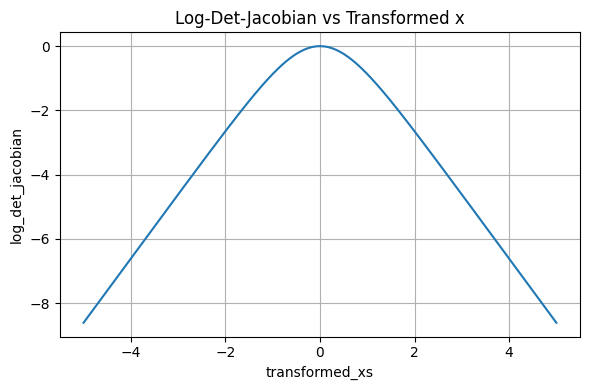

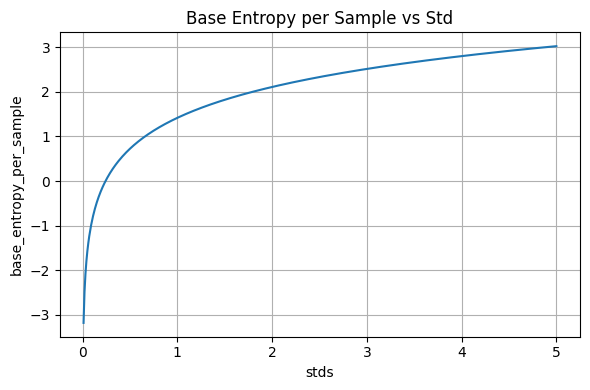

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# 1. Plot log_det_jacobian
transformed_xs = jnp.linspace(-5, 5, 500)
log_det_jacobian = 2 * (jnp.log(2) - transformed_xs - jax.nn.softplus(-2 * transformed_xs))

plt.figure(figsize=(6, 4))
plt.plot(transformed_xs, log_det_jacobian)
plt.title("Log-Det-Jacobian vs Transformed x")
plt.xlabel("transformed_xs")
plt.ylabel("log_det_jacobian")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Plot base_entropy_per_sample
stds = jnp.linspace(0.01, 5.0, 500)
base_entropy_per_sample = 0.5 * (jnp.log(2 * jnp.pi * jnp.e) + 2 * jnp.log(stds))

plt.figure(figsize=(6, 4))
plt.plot(stds, base_entropy_per_sample)
plt.title("Base Entropy per Sample vs Std")
plt.xlabel("stds")
plt.ylabel("base_entropy_per_sample")
plt.grid(True)
plt.tight_layout()
plt.show()
